In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.decomposition import TruncatedSVD
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df_songs = pd.read_csv('dataset.csv')

In [35]:
def in_top(pred_list,actual, top_x):
    return True if actual in list(pred_list.keys())[:top_x] else False

def logistic_reg_and_score(df: pd.DataFrame, num_words: int, n_grams:tuple =(1,1)):
    # Split the data into features (X) and target (y)
    X = df['lyrics_cleaned']
    y = df['parent_genre']

    # Split into training and test sets (80% training, 20% testing)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Create a pipeline: Vectorizer -> Logistic Regression
    # We use 'lbfgs' solver which is good for multiclass problems
    model_pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=num_words, stop_words='english', ngram_range=n_grams)),
        ('clf', LogisticRegression(solver='lbfgs', max_iter=1000,class_weight='balanced'))
    ])

    # Train the model
    print("Training model...")
    model_pipeline.fit(X_train, y_train)

    # Make predictions
    predictions = model_pipeline.predict(X_test)

    # Evaluate
    print(f"Accuracy: {accuracy_score(y_test, predictions):.2f}")
    print("\nClassification Report:\n")
    print(classification_report(y_test, predictions))

    # Get the probabilities
    probs = model_pipeline.predict_proba(X_test)

    # Get the genre names from the model
    genres = model_pipeline.classes_

    # Create a DataFrame where each column is a Genre
    y_prob = pd.DataFrame(probs, columns=genres, index=X_test.index)
    
    # This creates a dictionary of {Genre: Probability} for the top 3
    y_prob['predicted'] = y_prob.apply(
        lambda row: row.nlargest(3).to_dict(), 
        axis=1
    )

    df_pred = pd.DataFrame({
        'actual': y_test
    })

    df_pred = df_pred.join(y_prob['predicted'])
    for x in range(1,4):
        df_pred[f'top_{x}'] = df_pred.apply(lambda row: in_top(row['predicted'],row['actual'],x), axis=1)

    return df_pred

In [36]:
pred = logistic_reg_and_score(df_songs,9000,(1,1))

Training model...
Accuracy: 0.39

Classification Report:

                  precision    recall  f1-score   support

       Asian Pop       0.39      0.48      0.43        96
       Classical       0.11      0.34      0.16        44
      Electronic       0.57      0.30      0.39       882
    Folk/Country       0.44      0.57      0.50       322
   Hip-Hop & R&B       0.22      0.62      0.33        29
    Jazz & Blues       0.13      0.32      0.19        57
           Metal       0.54      0.71      0.61       452
             Pop       0.20      0.24      0.22       285
Reggae/Caribbean       0.43      0.48      0.45        86
            Rock       0.28      0.16      0.20       493
       Soul/Funk       0.16      0.27      0.20       157
  World/Regional       0.68      0.67      0.67       172

        accuracy                           0.39      3075
       macro avg       0.35      0.43      0.36      3075
    weighted avg       0.43      0.39      0.39      3075



Confusion Matrix (counts):
 [[ 43   3   8   3   5   2   4   4   8   6   3   4   3]
 [  1  15   2   7   0   1   2   6   3   0   2   2   3]
 [ 17  51 242  55  13  35  22 117 122  23  89  82  14]
 [  2  13  13 177   2  22   4  10  26   7  18  15  13]
 [  1   1   1   0  17   1   0   1   2   1   1   3   0]
 [  0   4   4   7   2  19   3   2   5   1   7   3   0]
 [  0   0   0   2   1   0   4   1   2   1   1   0   0]
 [  6  13  26  18  11   5   1 320  22   2  16   8   4]
 [ 11   8  51  35   2  23   3  26  74   4  20  24   4]
 [ 17   2   4   3   1   2   2   1   5  44   1   4   0]
 [ 11  29  53  60  19  23   8  95  63   5  67  47  13]
 [  3   8  25  18  11  11   5   3  14   1  10  44   4]
 [  2   4   7   9   0   4   3   7   2   7   3   9 115]]


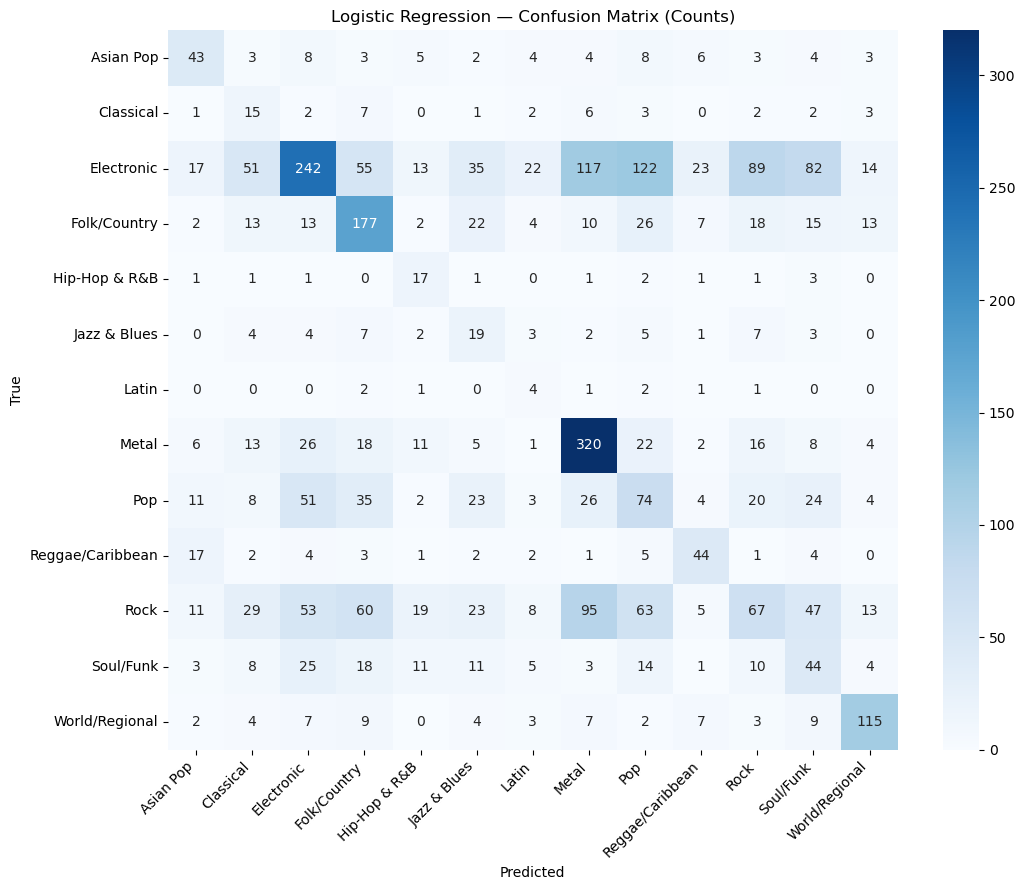

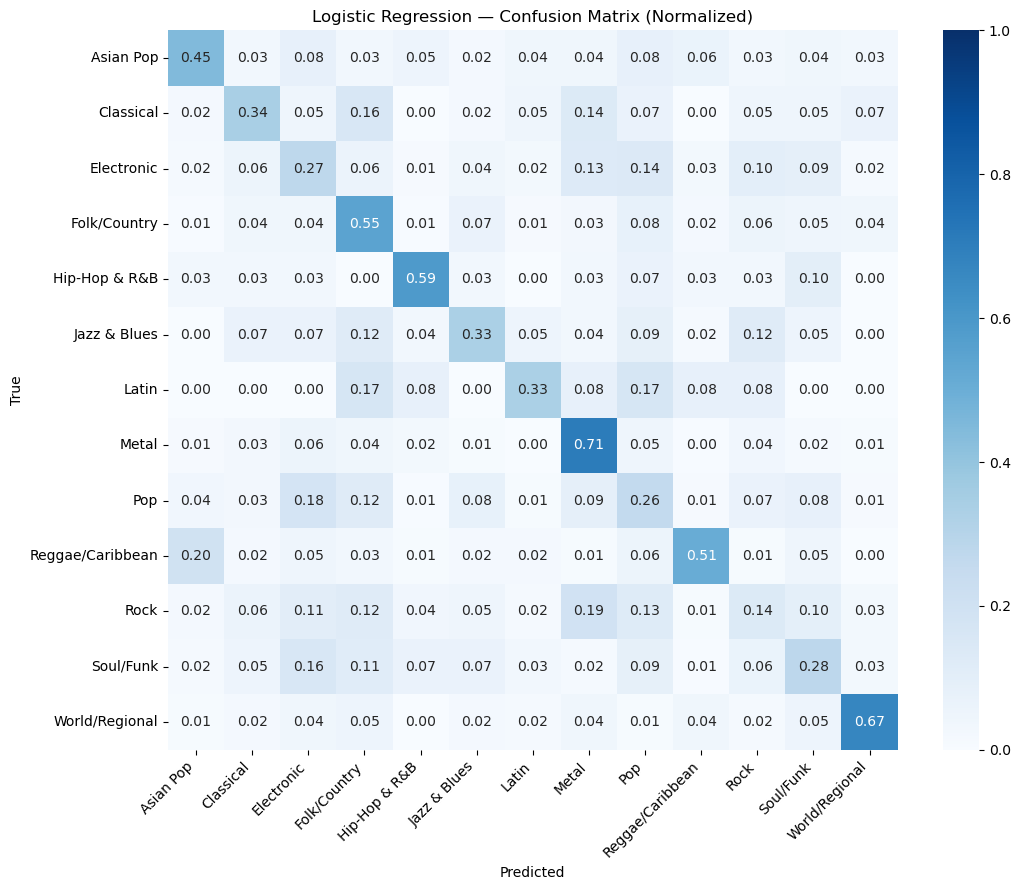

In [37]:
# Confusion Matrix

# Force EVERY element to a Python string. No exceptions, no edge cases.
y_test_arr      = np.array([str(x) for x in y_test], dtype=object)
predictions_arr = np.array([str(x) for x in predictions], dtype=object)
class_names     = [str(c) for c in model_pipeline.classes_]

# Confusion matrix
conf_matrix = confusion_matrix(y_test_arr, predictions_arr, labels=class_names)
print("Confusion Matrix (counts):\n", conf_matrix)

# Heatmap
plt.figure(figsize=(11, 9))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Logistic Regression — Confusion Matrix (Counts)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Normalized version
conf_matrix_norm = confusion_matrix(
    y_test_arr, predictions_arr, labels=class_names, normalize="true"
)

plt.figure(figsize=(11, 9))
sns.heatmap(
    conf_matrix_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    vmin=0,
    vmax=1,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Logistic Regression — Confusion Matrix (Normalized)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [38]:
num_words = []
top_1 = []
top_2 = []
top_3 = []

for x in range(7000,12500,500):
    pred = logistic_reg_and_score(df_songs,x)
    num_words.append(x)
    top_1.append(pred['top_1'].mean())
    top_2.append(pred['top_2'].mean())
    top_3.append(pred['top_3'].mean())

final_opt = pd.DataFrame({
    'num_words':num_words,
    'top_1_acc': top_1,
    'top_2_acc': top_2,
    'top_3_acc': top_3
})


Training model...
Accuracy: 0.39

Classification Report:

                  precision    recall  f1-score   support

       Asian Pop       0.40      0.48      0.44        96
       Classical       0.10      0.34      0.16        44
      Electronic       0.57      0.29      0.39       882
    Folk/Country       0.44      0.57      0.50       322
   Hip-Hop & R&B       0.23      0.62      0.33        29
    Jazz & Blues       0.13      0.32      0.18        57
           Metal       0.54      0.70      0.61       452
             Pop       0.20      0.24      0.22       285
Reggae/Caribbean       0.44      0.51      0.47        86
            Rock       0.27      0.15      0.20       493
       Soul/Funk       0.17      0.28      0.21       157
  World/Regional       0.67      0.66      0.67       172

        accuracy                           0.39      3075
       macro avg       0.35      0.43      0.36      3075
    weighted avg       0.43      0.39      0.39      3075

Training mo

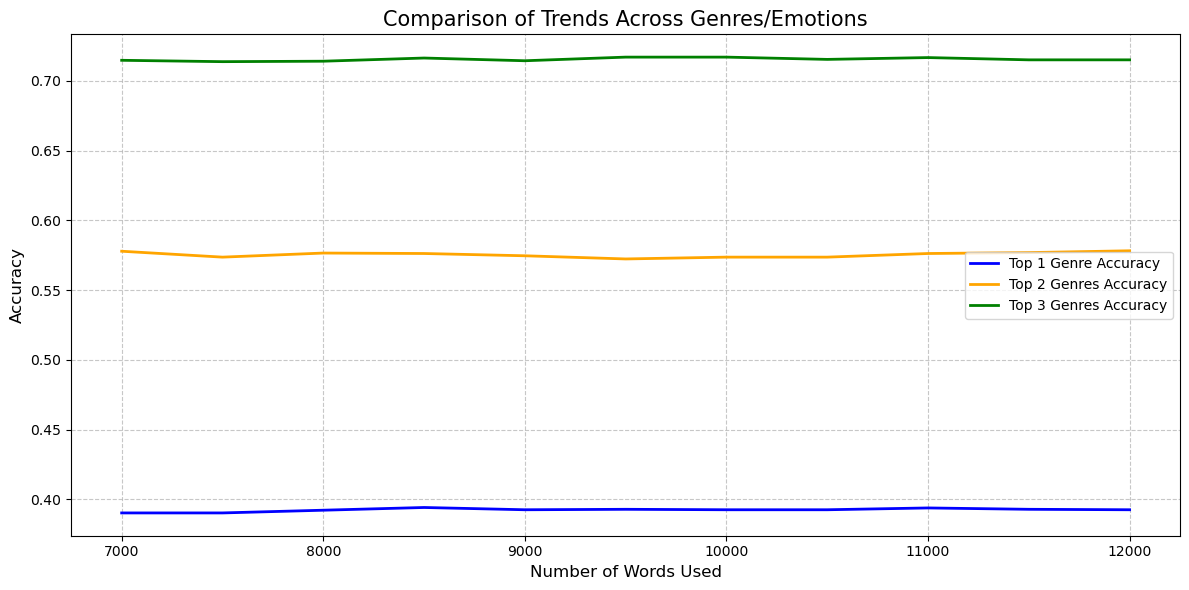

In [39]:
import matplotlib.pyplot as plt

# 1. Set the size of the plot
plt.figure(figsize=(12, 6))

# 2. Plot each column
# We use the dataframe index as the x-axis
plt.plot(final_opt['num_words'], final_opt['top_1_acc'], label='Top 1 Genre Accuracy', color='blue', linewidth=2)
plt.plot(final_opt['num_words'], final_opt['top_2_acc'], label='Top 2 Genres Accuracy', color='orange', linewidth=2)
plt.plot(final_opt['num_words'], final_opt['top_3_acc'], label='Top 3 Genres Accuracy', color='green', linewidth=2)

# 3. Add styling
plt.title('Comparison of Trends Across Genres/Emotions', fontsize=15)
plt.xlabel('Number of Words Used', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()  # This adds the key so you know which color is which
plt.grid(True, linestyle='--', alpha=0.7)

# 4. Display the plot
plt.tight_layout()
plt.show()


In [40]:
genres = df_songs['parent_genre'].unique()

def fit_model(X_train,y_train, num_words):
    # Create a pipeline: Vectorizer -> Logistic Regression
    # We use 'lbfgs' solver which is good for multiclass problems
    model_pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=num_words, stop_words='english')),
        ('clf', LogisticRegression(solver='lbfgs', max_iter=1000,class_weight='balanced'))
    ])

    # Train the model
    print("Training model...")
    model_pipeline.fit(X_train, y_train)
    return model_pipeline

def logistic_reg_and_score(df: pd.DataFrame):
    # Split the data into features (X) and target (y)
    X = df['lyrics_cleaned']
    y = df['parent_genre']
    y_unique = y.unique()

    
    # Split into training and test sets (80% training, 20% testing)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    large_model = fit_model(X_train,y_train,9000)
    # Make predictions
    predictions = large_model.predict(X_test)

    # Get the probabilities
    probs = large_model.predict_proba(X_test)

    # Get the genre names from the model
    genres = large_model.classes_

    # Create a DataFrame where each column is a Genre
    y_prob = pd.DataFrame(probs, columns=genres, index=X_test.index)
    
    # This creates a dictionary of {Genre: Probability} for the top 3
    y_prob['predicted'] = y_prob.apply(
        lambda row: row.nlargest(3).to_dict(), 
        axis=1
    )

    df_pred = pd.DataFrame({
        'actual': y_test,
        'lyrics_cleaned':X_test
    })

    df_pred = df_pred.join(y_prob['predicted'])

    combined_xy_train = X_train.to_frame().join(y_train)
    combined_xy_test = X_test.to_frame().join(y_test)
    combos_models = {}
    for i in range(len(y_unique)):
        for j in range(i+1,len(y_unique)):
            for k in range(j+1,len(y_unique)):
                combo_tuple = (y_unique[i],y_unique[j],y_unique[k])
                print("Currently on combo:",combo_tuple)
                sub_x_y_train = combined_xy_train[combined_xy_train['parent_genre'].isin([y_unique[i],y_unique[j],y_unique[k]])]
                sub_x_y_test = combined_xy_test[combined_xy_test['parent_genre'].isin([y_unique[i],y_unique[j],y_unique[k]])]
                sub_model = fit_model(sub_x_y_train['lyrics_cleaned'],sub_x_y_train['parent_genre'],1000)
                sub_predictions = sub_model.predict(sub_x_y_test['lyrics_cleaned'])
                combos_models[combo_tuple] = (sub_model,accuracy_score(sub_x_y_test['parent_genre'],sub_predictions))
    
    return combos_models,df_pred

model_dict,predicts = logistic_reg_and_score(df_songs)


Training model...
Currently on combo: ('World/Regional', 'Rock', 'Electronic')
Training model...
Currently on combo: ('World/Regional', 'Rock', 'Asian Pop')
Training model...
Currently on combo: ('World/Regional', 'Rock', 'Metal')
Training model...
Currently on combo: ('World/Regional', 'Rock', 'Folk/Country')
Training model...
Currently on combo: ('World/Regional', 'Rock', 'Jazz & Blues')
Training model...
Currently on combo: ('World/Regional', 'Rock', 'Classical')
Training model...
Currently on combo: ('World/Regional', 'Rock', 'Reggae/Caribbean')
Training model...
Currently on combo: ('World/Regional', 'Rock', 'Soul/Funk')
Training model...
Currently on combo: ('World/Regional', 'Rock', 'Hip-Hop & R&B')
Training model...
Currently on combo: ('World/Regional', 'Rock', 'Pop')
Training model...
Currently on combo: ('World/Regional', 'Electronic', 'Asian Pop')
Training model...
Currently on combo: ('World/Regional', 'Electronic', 'Metal')
Training model...
Currently on combo: ('World/Re

KeyboardInterrupt: 

In [62]:
predicts = predicts.join(df_songs['lyrics_cleaned'])


In [70]:
predictions = []
for dict_top_3,lyrics in zip(predicts['predicted'].to_list(),predicts['lyrics_cleaned'].to_list()):
    for model_key,model in model_dict.items():
        correct_model = True
        for top_3_key in dict_top_3.keys():
            if top_3_key not in model_key:
                correct_model=False
        if correct_model:
            probs = model[0].predict_proba([lyrics])[0]
            genres = model[0].classes_
            current_max_prob = 0
            current_max_genre = ''
            for i in range(len(probs)):
                combined_prob = probs[i]*dict_top_3[genres[i]]
                if combined_prob > current_max_prob:
                    current_max_prob = combined_prob
                    current_max_genre = genres[0]
            predictions.append(current_max_genre)


In [71]:
predicts['final_prediction'] = predictions

In [ ]:
predicts['correct'] = predicts['actual']==predicts['final_prediction']

In [76]:
avg_acc = 0.0
for key, accuracy in model_dict.items():
    avg_acc += accuracy[1]

avg_acc = avg_acc/len(model_dict)
print(avg_acc)

0.7497221811844668
